<div style="max-width:300px; float: left; margin-right: 1em">

![](Figures/fcfm_das.svg)

</div>
<span style="color: red;">Departamento de Astronomía, Universidad de Chile</span> <br>
Facultad de Ciencias Físicas y Matemáticas <br>
Universidad de Chile <br>
AS4501 - Astroinformatica <br>
Otoño 2026 <br>
Profesor: Francisco Förster Burón <br>
<strong>Profesores Auxilares y Autores: Benjamin Carrera y Steve Jurado</strong> <br>

> This notebook is created based on the notes from 
> - ([@fforster](https://github.com/fforster)) Francisco Förster: - **Main Notes 2026/01**   
>   - https://github.com/fforster/AS4501/tree/main
> - ([@thevalentino](https://github.com/thevalentino)) Valentino Gonzales:
>   - https://github.com/thevalentino/AS450-astroinformatica
> - ([@cefuente](https://github.com/cefuente)) Cesar Fuentes
>   - https://github.com/cefuente/astroinformatica
> and previour teachers assistants
> - ([@m-fuentealba](https://github.com/m-fuentealba)) Melissa Fuentealba 
> - ([@jvines](https://github.com/jvines)) José Vines
> - ([@PauCaBu](https://github.com/PauCaBu)) Paula Cáceres Burgos
> - ([@JavieraTGrey](https://github.com/JavieraTGrey)) Javiera Toro Grey

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
try:
   from astropy.table import vstack
except:
   !pip install astropy
   from astropy.table import vstack
try:
   from astroquery.gaia import Gaia
except:
   !pip install astroquery
   from astroquery.gaia import Gaia

rc_params = {
    # --- Fonts and text ---
    'mathtext.fontset': 'cm',     # Set default mathtext font
    'font.family': 'STIXGeneral', # Set default font family
    
    # --- Figure and axes ---
    'font.size': 12,              # Set default font size
    'axes.labelsize': 16,         # Set default axes label size
    'axes.titlesize': 16,         # Set default axes title size
    'xtick.labelsize': 14,        # Set default axes label size
    'ytick.labelsize': 14,        # Set default axes label size
    'legend.fontsize': 14,        # Set default legend font size
    
    # --- Configuration of ticks ---
    'xtick.direction': 'in',      # Set default xtickdirecion
    'ytick.direction': 'in',      # Set default ytickdirecion
    'xtick.minor.visible': True,  # visibility of minor ticks on x-axis
    'ytick.minor.visible': True,  # visibility of minor ticks on y-axis


    'grid.linestyle': ':',        # Set grid linestyle
    'grid.alpha': 0.6,            # Set grid transparency
    
    # --- Figure size ---
    'figure.figsize': (8, 6),     # Proporción ideal para una columna de MNRAS
}
plt.rcParams.update(rc_params)

The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive

The GACS will be under maintenance on 15 April from 11:00 to 13:00 CEST approximately, for the upgrade to version 3.12.0. Apologies for the inconveniences.


In this project, we utilize data from Gaia DR3 to perform a classification task on Variable Stars. These are celestial objects that exhibit fluctuations in their luminosity over time.

We focus on the three most common types found in the Gaia catalogs:

- **Cepheids (CEP):** High-mass, highly luminous stars (giants and supergiants). They occupy the upper section of the instability strip in the HR diagram.

- **RR Lyrae (RR):** Older, low-mass stars. They are less luminous than Cepheids and are typically found on the "Horizontal Branch."

- **Delta Scuti (DSCT):** Stars located on the Main Sequence or slightly evolved from it. They exhibit lower luminosity compared to the previous classes and higher frequencies in their pulsations.

In [2]:
n_samples = 500 
tables = []
classes = ['RR', 'CEP', 'DSCT/GDOR/SXPHE']

for cls in classes:
    print(f"\n[1] Iniciando consulta para: {cls}...")
    
    q = f"""
    SELECT TOP {n_samples}
        g.source_id, g.ra, g.dec, g.parallax, g.pmra, g.pmdec,
        g.phot_g_mean_mag, g.bp_rp,
        v.best_class_name AS target_class
    FROM gaiadr3.gaia_source AS g
    JOIN gaiadr3.vari_classifier_result AS v
        ON g.source_id = v.source_id
    WHERE g.parallax_over_error > 5
        AND g.bp_rp IS NOT NULL
        AND v.best_class_name = '{cls}'
    ORDER BY g.random_index
    """
    
    # Forzamos una limpieza de caché en caso de que astroquery haya guardado un error previo
    job = Gaia.launch_job_async(q)
    t = job.get_results()
    
    # AUDITORÍA DE DESCARGA
    print(f" -> Filas descargadas desde Gaia: {len(t)}")
    
    if len(t) > 0:
        tables.append(t)

print("\n[2] Apilando tablas (vstack)...")
results = vstack(tables)

# Convertimos a Pandas
df = results.to_pandas()


[1] Iniciando consulta para: RR...
INFO: Query finished. [astroquery.utils.tap.core]
 -> Filas descargadas desde Gaia: 500

[1] Iniciando consulta para: CEP...
INFO: Query finished. [astroquery.utils.tap.core]
 -> Filas descargadas desde Gaia: 500

[1] Iniciando consulta para: DSCT/GDOR/SXPHE...
INFO: Query finished. [astroquery.utils.tap.core]
 -> Filas descargadas desde Gaia: 0

[2] Apilando tablas (vstack)...


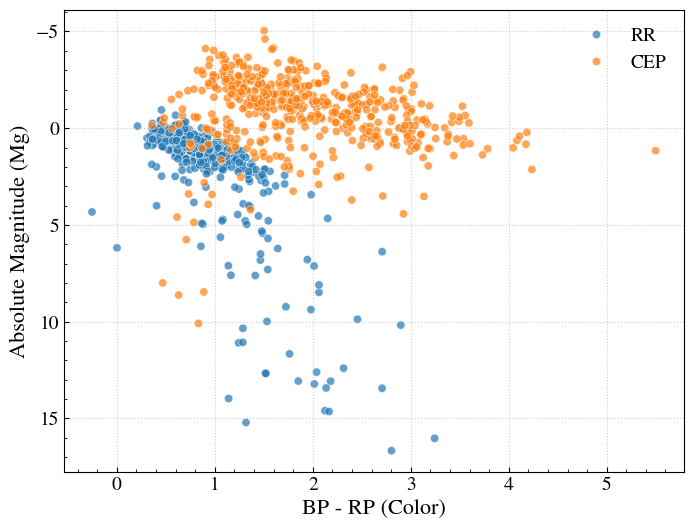

In [10]:
# Absolute Magnitude (Mg)
# Mg = G + 5 * log10(parallax) - 10
df['Mg'] = df['phot_g_mean_mag'] + 5 * np.log10(df['parallax']) - 10

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='bp_rp',
    y='Mg',
    hue='target_class',
    #palette='viridis',
    alpha=0.7
)
ax.invert_yaxis()
ax.set_xlabel('BP - RP (Color)')
ax.set_ylabel('Absolute Magnitude (Mg)')
ax.legend(title='', frameon=False)
ax.grid()
plt.show()

In [12]:

# Forzamos la columna target_class a string estándar (a veces Astropy la deja como bytes tipo b'CEP')
df['target_class'] = df['target_class'].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else str(x))

print(f" -> Tamaño del DataFrame crudo: {df.shape[0]} filas.")
print(df['target_class'].value_counts())

print("\n[4] Mezclando datos (shuffle)...")
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nDistribución final de clases lista para Machine Learning:")
print(df['target_class'].value_counts())

 -> Tamaño del DataFrame crudo: 1000 filas.
target_class
RR     500
CEP    500
Name: count, dtype: int64

[4] Mezclando datos (shuffle)...

Distribución final de clases lista para Machine Learning:
target_class
CEP    500
RR     500
Name: count, dtype: int64


In [13]:
df_final.columns

Index(['source_id', 'ra', 'dec', 'parallax', 'pmra', 'pmdec',
       'phot_g_mean_mag', 'bp_rp', 'target_class', 'Mg'],
      dtype='str')

We will begin with the classification task. First we need to defined a train and test dataset. For this we will use the library `sklearn`

## $K$-Nearest Neighbors (KNN)

The K-Nearest Neighbors (KNN) algorithm is a non-parametric supervised learning method used for classification. In the context of variable stars, the algorithm predicts the class of a target star by analyzing its $k$ closest neighbors within a multidimensional feature space (e.g., color, absolute magnitude, and parallax).

Given a labeled training set $\{(\mathbf{x}_i, y_i)\}_{i=1}^{N}$, KNN classifies a new point $\mathbf{x}$ by finding its $k$ closest neighbors under a distance metric typically the Euclidean distance:

$$d(\mathbf{x}, \mathbf{x}_i) = \sqrt{\sum_{j=1}^{p}(x_j - x_{i,j})^2}$$

The predicted class is the **majority vote** among the $k$ nearest neighbors:

$$\hat{y} = \underset{c}{\arg\max} \sum_{i \in \mathcal{N}_k(\mathbf{x})} \mathbf{1}[y_i = c]$$

where $\mathcal{N}_k(\mathbf{x})$ is the set of the $k$ closest points to $\mathbf{x}$

To improve performance in regions where stellar populations overlap, we can assign a weight $w_i$ to each neighbor inversely proportional to its distance:$$w_i = \frac{1}{d(\mathbf{x}, \mathbf{x}_i)^2}$$This ensures that more "similar" stars have a greater influence on the classification than those at the outskirts of the $k$-neighborhood.

**Effect of $k$:**
- Small $k$ → Low bias, high variance. The model is sensitive to noise (e.g., photometric errors in Gaia DR3) and outliers.
- Large $k$ → High bias, low variance. It produces smoother decision boundaries but may overlook small-scale structures in the instability strip.

> **Important:** KNN is sensitive to feature scale. Features with larger ranges dominate the distance.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier


# First we select the physical features that we will use for the classification
# In this case, we will as features Mg, bp_rp, parallax, pmra, pmdec and as target the
# target_class.

X = df[['Mg', 'bp_rp', 'parallax', 'pmra', 'pmdec']]
y = df['target_class']

# Lets split the data into training and testing sets, using 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Now we will create a KNN classifier and fit it to the training data
knn   = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

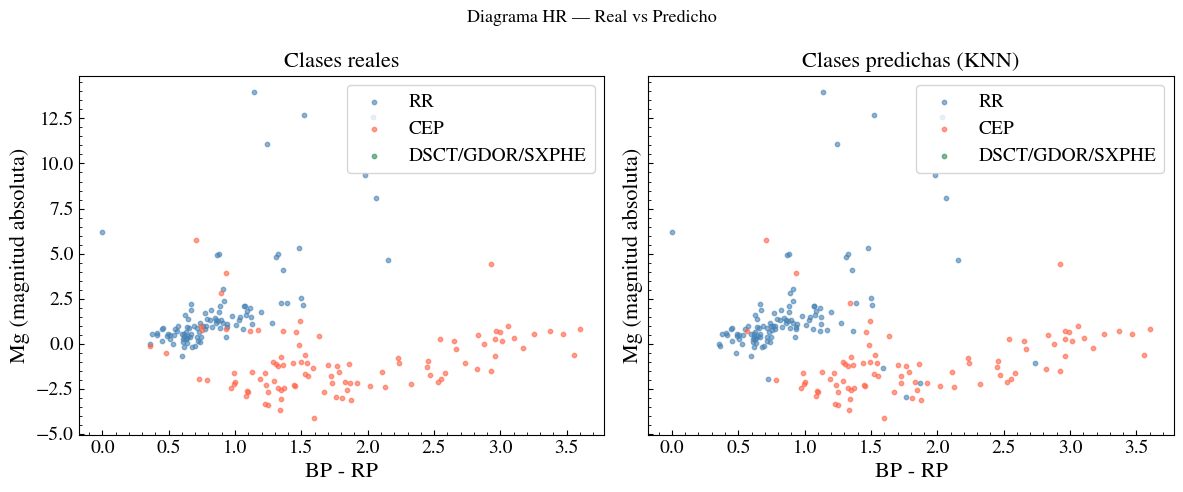

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

colors = {'RR': 'steelblue', 'CEP': 'tomato', 'DSCT/GDOR/SXPHE': 'seagreen'}

for ax, labels, title in zip(axes,
                              [y_test, y_pred],
                              ['Clases reales', 'Clases predichas (KNN)']):
    for cls, color in colors.items():
        mask = labels == cls
        ax.scatter(X_test.loc[mask, 'bp_rp'],
                   X_test.loc[mask, 'Mg'],
                   c=color, label=cls, s=10, alpha=0.6)
    ax.set_xlabel('BP - RP')
    ax.set_ylabel('Mg (magnitud absoluta)')
    ax.invert_yaxis()
    ax.set_title(title)
    ax.legend()

plt.suptitle('Diagrama HR — Real vs Predicho', fontsize=13)
plt.tight_layout()
plt.show()

Hya una manera gráfica para ver como de bien nuestro modelo predice, esto es unsado la matrix de confusión tambien dentor de la librería `sklearn`

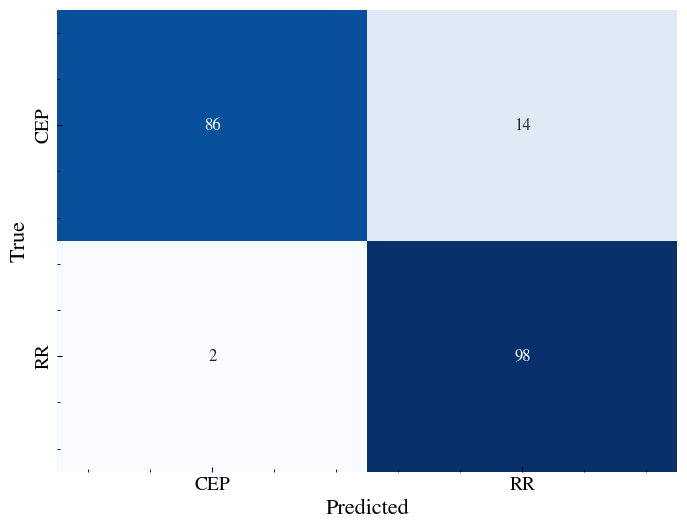

In [32]:
from sklearn.metrics import confusion_matrix

fig, ax = plt.subplots()
cm = confusion_matrix(y_test, y_pred, labels=knn.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=knn.classes_, yticklabels=knn.classes_, cbar=False, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')

plt.show()


We now compute the standard classification metrics: precision, recall, F1-score, and accuracy. For a given class $c$, we define:

- **True Positives (TP):** samples of class $c$ correctly predicted as $c$
- **False Positives (FP):** samples of other classes incorrectly predicted as $c$
- **False Negatives (FN):** samples of class $c$ incorrectly predicted as another class

The metrics are then defined as:

$$\text{Precision} = \frac{TP}{TP + FP}$$

$$\text{Recall} = \frac{TP}{TP + FN}$$

$$\text{F1-score} = 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} = \frac{2\,TP}{2\,TP + FP + FN}$$

$$\text{Accuracy} = \frac{\sum_c TP_c}{\text{Total samples}}$$


To CEP class

$$\text{Precision}_{CEP} = \frac{86}{86+2} = \frac{86}{88} \approx 0.977$$

$$\text{Recall}_{CEP} = \frac{86}{86+14} = \frac{86}{100} = 0.860$$

$$\text{F1}_{CEP} = \frac{2 \times 86}{2\times86 + 2 + 14} = \frac{172}{188} \approx 0.915$$


For RR class:
$$\text{Precision}_{RR} = \frac{98}{98+14} = \frac{98}{112} \approx 0.875$$

$$\text{Recall}_{RR} = \frac{98}{98+2} = \frac{98}{100} = 0.980$$

$$\text{F1}_{RR} = \frac{2 \times 98}{2\times98 + 14 + 2} = \frac{196}{212} \approx 0.925$$


Accuracy global:

$$\text{Accuracy} = \frac{86 + 98}{86+14+2+98} = \frac{184}{200} = 0.920$$






For multi-class problems (as in our case: RR, CEP, DSCT/GDOR/SXPHE), these metrics are computed **per class** and then averaged. `classification_report` uses **macro averaging** by default:

$$\overline{\text{F1}} = \frac{1}{C} \sum_{c=1}^{C} \text{F1}_c$$

where $C$ is the number of classes.
skelarn tiene dentro de su mismo código una forma calcular las metricas por si mismo a través de moetodo

from sklearn.metrics import classification_report

In [34]:
# Finally, we will evaluate the performance of the classifier on the test set
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         CEP       0.98      0.86      0.91       100
          RR       0.88      0.98      0.92       100

    accuracy                           0.92       200
   macro avg       0.93      0.92      0.92       200
weighted avg       0.93      0.92      0.92       200



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


# 1. MATRIZ DE CONFUSIÓN
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.title('Matriz de Confusión: Clasificación de Variables Gaia')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Clase Real (Catálogo)')
plt.show()

# 2. IMPORTANCIA DE CARACTERÍSTICAS
importancias = clf.feature_importances_
indices = np.argsort(importancias)[::-1]
nombres_features = [caracteristicas[i] for i in indices]

plt.figure(figsize=(10, 6))
plt.title("Importancia de las Características Físicas")
plt.bar(range(X.shape[1]), importancias[indices], align="center", color='skyblue')
plt.xticks(range(X.shape[1]), nombres_features)
plt.ylabel("Peso relativo en la decisión")
plt.show()

NameError: name 'clf' is not defined

<Figure size 1000x800 with 0 Axes>

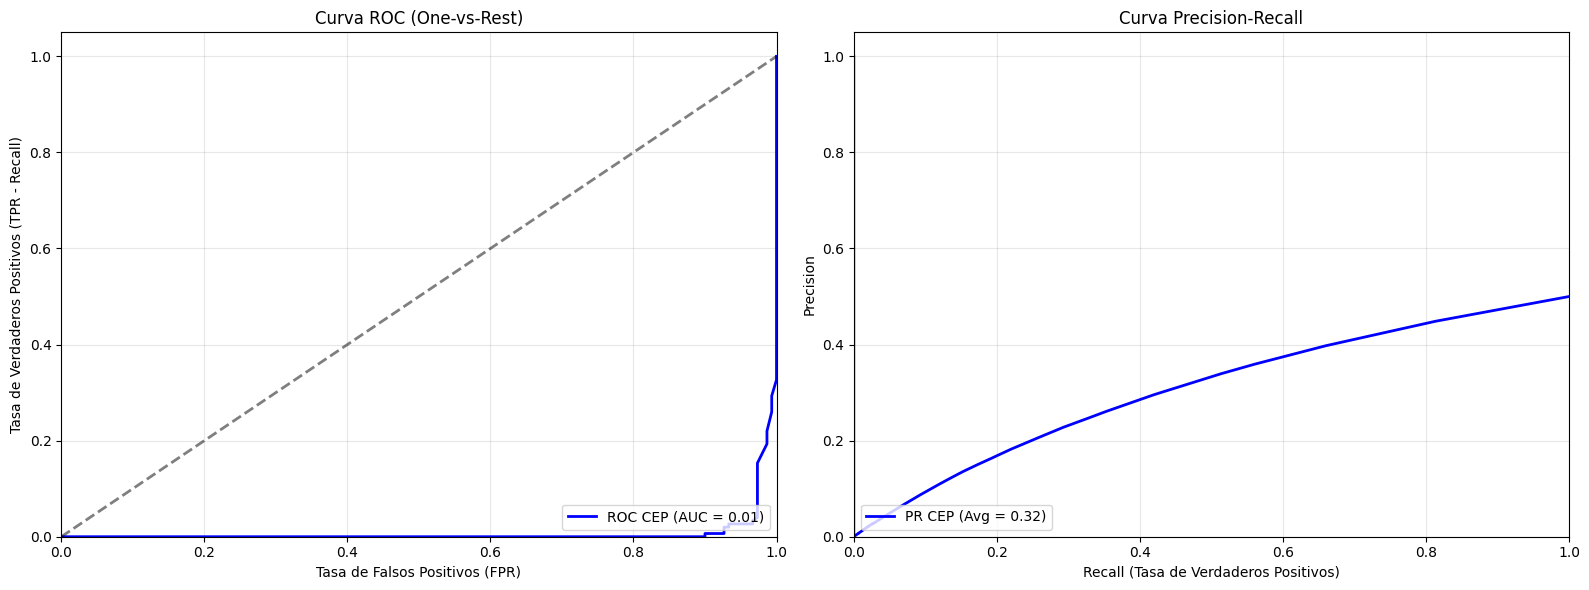

In [24]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

# 1. Binarizar las etiquetas para el enfoque One-vs-Rest
# Convierte ['RR', 'CEP', 'DSCT'] a columnas de 0s y 1s
y_test_bin = label_binarize(y_test, classes=clf.classes_)
n_classes = y_test_bin.shape[1]

# 2. Obtener las probabilidades de predicción del modelo
# En lugar de clf.predict(), usamos predict_proba()
y_score = clf.predict_proba(X_test)

# Configurar los gráficos (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Colores para cada clase
colors = ['blue', 'green', 'darkorange']

for i, color in zip(range(n_classes), colors):
    clase_actual = clf.classes_[i]
    
    # --- GRÁFICO 1: Curva ROC ---
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, color=color, lw=2, 
             label=f'ROC {clase_actual} (AUC = {roc_auc:.2f})')
    
    # --- GRÁFICO 2: Curva Precision-Recall ---
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
    avg_pr = average_precision_score(y_test_bin[:, i], y_score[:, i])
    ax2.plot(recall, precision, color=color, lw=2, 
             label=f'PR {clase_actual} (Avg = {avg_pr:.2f})')

# Formato del Gráfico ROC
ax1.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5) # Línea de clasificador aleatorio
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax1.set_ylabel('Tasa de Verdaderos Positivos (TPR - Recall)')
ax1.set_title('Curva ROC (One-vs-Rest)')
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

# Formato del Gráfico Precision-Recall
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall (Tasa de Verdaderos Positivos)')
ax2.set_ylabel('Precision')
ax2.set_title('Curva Precision-Recall')
ax2.legend(loc="lower left")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

/home/jurados/AS4501_Astroinformatic/Astroinformatic/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


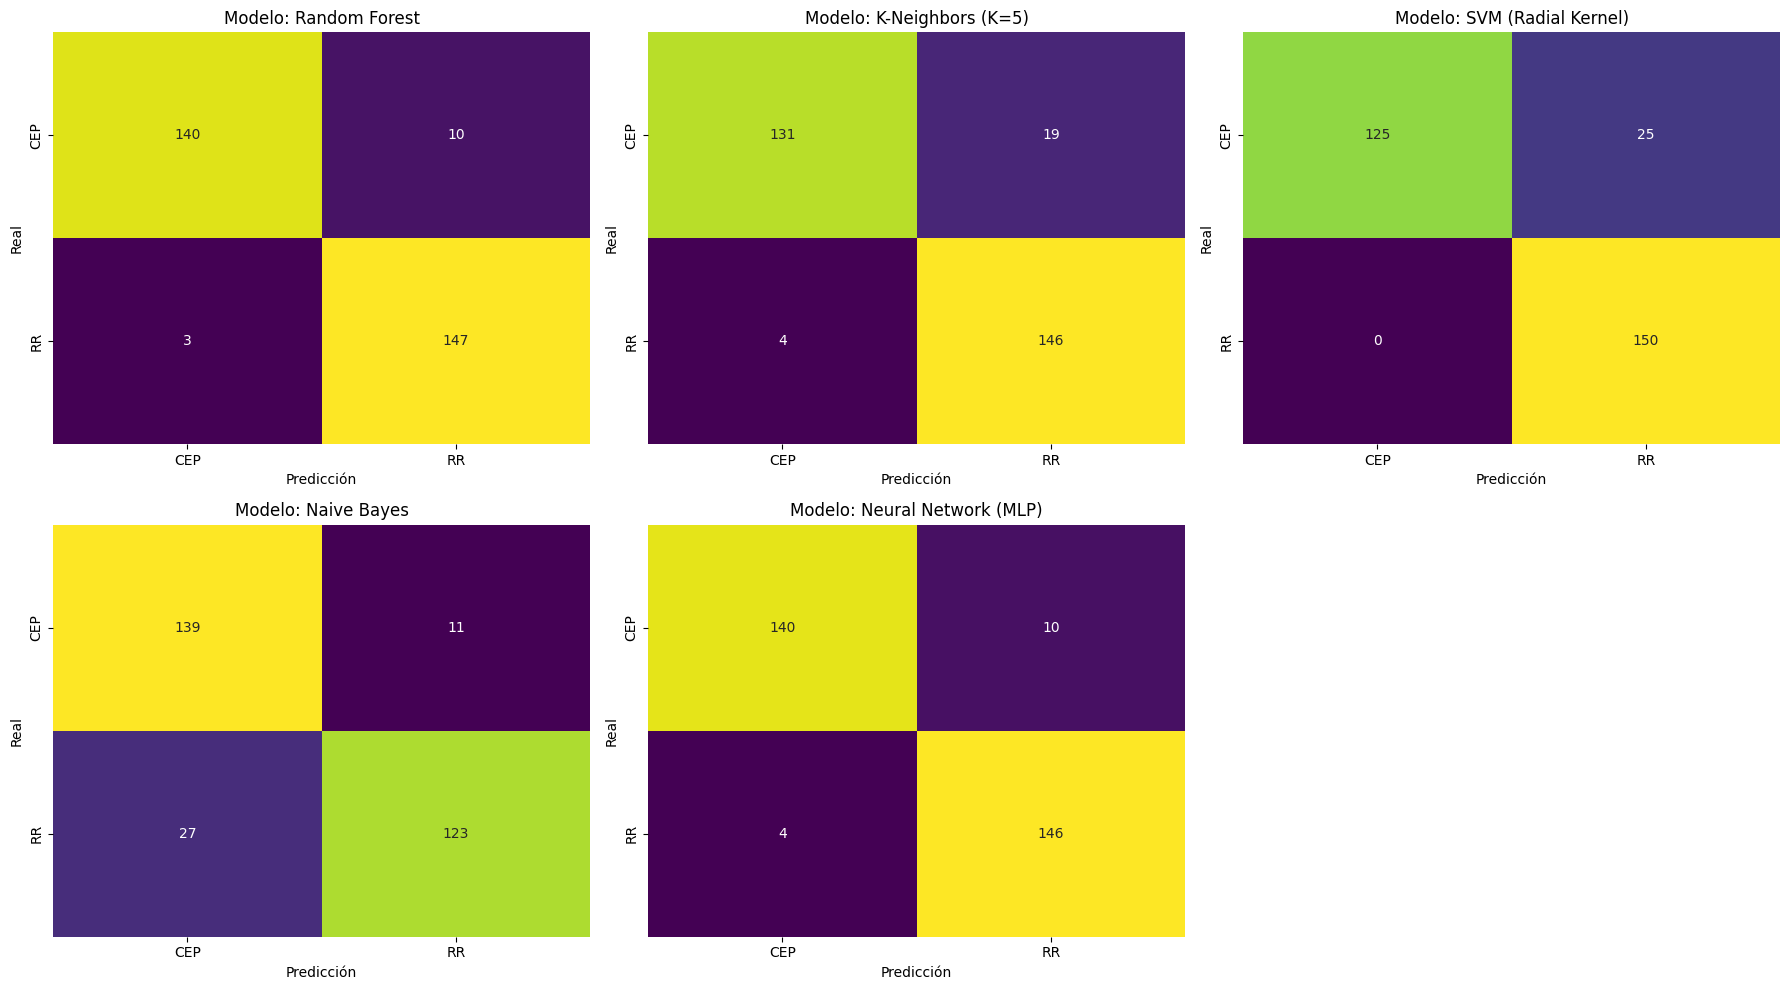

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix

# 1. Definimos el diccionario de modelos
modelos = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "K-Neighbors (K=5)": KNeighborsClassifier(n_neighbors=5),
    "SVM (Radial Kernel)": SVC(probability=True, random_state=42),
    "Naive Bayes": GaussianNB(),
    "Neural Network (MLP)": MLPClassifier(max_iter=500, random_state=42)
}

# 2. Configuramos la grilla de gráficos (2 filas, 3 columnas)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# 3. Entrenamos y graficamos cada uno
for i, (nombre, clf) in enumerate(modelos.items()):
    ax = axes[i]
    
    # Entrenamiento
    clf.fit(X_train, y_train)
    
    # Predicción
    y_pred_m = clf.predict(X_test)
    
    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred_m, labels=clf.classes_)
    
    # Visualización
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', 
                xticklabels=clf.classes_, yticklabels=clf.classes_, ax=ax, cbar=False)
    
    ax.set_title(f'Modelo: {nombre}')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')

# Eliminamos el último eje vacío (el sexto)
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

In [26]:
# --- CREACIÓN DEL ESCENARIO DESBALANCEADO ---
# Supongamos que tenemos 2000 RR Lyrae pero solo 50 Cefeidas y 50 Delta Scuti
df_rr = df_final[df_final['target_class'] == 'RR'].sample(2000, replace=True)
df_cep = df_final[df_final['target_class'] == 'CEP'].sample(50)
df_dsct = df_final[df_final['target_class'] == 'DSCT/GDOR/SXPHE'].sample(50)

df_imbalanced = pd.concat([df_rr, df_cep, df_dsct]).sample(frac=1)

# Preparar datos
X_imb = df_imbalanced[['abs_mag_g', 'bp_rp', 'pmra', 'pmdec']]
y_imb = df_imbalanced['target_class']
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(X_imb, y_imb, test_size=0.3, stratify=y_imb)

# --- ENTRENAMIENTO ---
clf_imb = RandomForestClassifier(random_state=42)
clf_imb.fit(X_train_i, y_train_i)
y_pred_i = clf_imb.predict(X_test_i)

# --- EVALUACIÓN CRÍTICA ---
print("--- RESULTADOS CON DATOS DESBALANCEADOS ---")
print(f"Exactitud Balanceada: {balanced_accuracy_score(y_test_i, y_pred_i):.2f}")
print(classification_report(y_test_i, y_pred_i))

ValueError: a must be greater than 0 unless no samples are taken

In [27]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Definimos el esquema de validación: 5 divisiones (Folds)
# Shuffle=True es vital para asegurar que los datos no estén ordenados
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Usamos el dataset original balanceado (X, y definido anteriormente)
clf_cv = RandomForestClassifier(n_estimators=100, random_state=42)

# Calculamos la exactitud para cada uno de los 5 experimentos
scores = cross_val_score(clf_cv, X, y, cv=skf, scoring='accuracy')

print("--- RESULTADOS DE VALIDACIÓN CRUZADA (5-FOLD) ---")
print(f"Exactitudes por Fold: {scores}")
print(f"Exactitud Promedio: {scores.mean():.4f} +/- {scores.std():.4f}")

# Esto demuestra la estabilidad del modelo ante diferentes subconjunt

--- RESULTADOS DE VALIDACIÓN CRUZADA (5-FOLD) ---
Exactitudes por Fold: [0.95  0.96  0.985 0.97  0.945]
Exactitud Promedio: 0.9620 +/- 0.0144


Ranking de simplicidad en sklearn:

Modelo	Parámetros mínimos	Explicabilidad
KNN	1 (k)	Alta
Decision Tree	1 (max_depth)	Alta
Logistic Regression	1 (C)	Media
Random Forest	2+	Media
SVM	2+	Baja
Para un auxiliar de ML supervisado, KNN o Decision Tree son los mejores puntos de partida antes de introducir modelos más complejos.